# CIC-IDS2017 Binary Classification

This notebook builds and evaluates a classical machine learning intrusion detection system using CIC-IDS2017 labelled flow CSV data.

The task is binary classification: each network-flow record is classified as either `Benign` or `Malicious`. The notebook follows the same workflow as the report:

1. load the CIC-IDS2017 CSV files used for the experiment;
2. clean the data and inspect the class balance;
3. split the data into training, validation, and final test sets;
4. train several baseline and stronger machine learning models;
5. tune the strongest candidate model;
6. compare model performance using validation and test metrics;
7. save and reload the best model to prove the result is reproducible.


In [1]:
from pathlib import Path
import warnings
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Work from the project root whether the notebook is opened from the root folder or notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

# Import the reusable project functions used by both the notebook and Python scripts.
from aics_ids_pipeline import (
    HIST_GRADIENT_BOOSTING_PARAM_GRID,
    TUNING_CV_FOLDS,
    TUNING_SCORING,
    best_model_name,
    build_models,
    clean_dataset,
    find_csv_files,
    load_csv_files,
    prepare_binary_dataset,
    save_model,
    train_and_evaluate,
    tune_hist_gradient_boosting,
)

# Main project folders. Outputs from this notebook are saved into models/ and figures/.
DATA_DIR = PROJECT_ROOT / "data" / "dataset"
FULL_DATA_DIR = PROJECT_ROOT / "data" / "full_dataset" / "MachineLearningCVE"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def display_table(df, caption=None, precision=4, hide_index=False):
    """Display a small report-style table with consistent formatting."""
    styler = (
        df.style
        .format(precision=precision, thousands=",", na_rep="-")
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("background-color", "#eef2f7"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("padding", "6px 10px")]},
        ])
    )
    if caption:
        styler = styler.set_caption(caption)
    if hide_index:
        styler = styler.hide(axis="index")
    display(styler)


## Load Data

The notebook reads every CSV file placed in `data/dataset/`. To use a different CIC-IDS2017 CSV set, place those CSV files in `data/dataset/` and run the notebook again.

The complete original dataset is kept separately in `data/full_dataset/MachineLearningCVE/` so it is available for reference, but it is not loaded by default. This prevents the notebook from accidentally training on the entire dataset when a smaller coursework run is needed.

`ROWS_PER_FILE = 75_000` means the notebook randomly samples up to 75,000 rows from each CSV file in `data/dataset/`. Set it to `None` to use every row from the CSVs in that folder.


In [2]:
# Limit the number of rows loaded from each CSV so the notebook can be re-run on a laptop.
# Set this to None if the marker wants to train on every row in data/dataset/.
ROWS_PER_FILE = 75_000

# Find every CSV in data/dataset/. A marker can replace these CSVs with their own dataset files.
csv_files = find_csv_files(DATA_DIR)
if not csv_files:
    raise FileNotFoundError("No CSV files found. Place CIC-IDS2017 CSV files in data/dataset/ and run again.")

dataset_files_table = pd.DataFrame({
    "csv_file": [path.name for path in csv_files],
    "relative_path": [str(path.relative_to(PROJECT_ROOT)) for path in csv_files],
})
display_table(dataset_files_table, "CSV files loaded from data/dataset", hide_index=True)


csv_file,relative_path
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,data/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,data/dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv,data/dataset/Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv,data/dataset/Wednesday-workingHours.pcap_ISCX.csv


In [3]:
# Load the CSV files from data/dataset/ into one combined dataframe.
df = load_csv_files(csv_files, rows_per_file=ROWS_PER_FILE)

# Record the loaded shape so the report can state how much data was used.
load_summary = pd.DataFrame([
    {
        "csv_files_loaded": len(csv_files),
        "rows_per_file_limit": ROWS_PER_FILE,
        "loaded_rows": df.shape[0],
        "loaded_columns": df.shape[1],
    }
])
display_table(load_summary, "Loaded dataset shape", hide_index=True)


csv_files_loaded,rows_per_file_limit,loaded_rows,loaded_columns
4,"75,000","300,000",80


In [4]:
# Preview the first rows to confirm the flow features and Label column loaded correctly.
display_table(df.head(5), "First five loaded records", hide_index=True)


Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
80,"9,392,887",4,0,24,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,2.5551,0.4259,"3,130,962.3330","5,421,269.3760","9,390,905",975,"9,392,887","3,130,962.3330","5,421,269.3760","9,390,905",975,0,0.0000,0.0000,0,0,0,0,0,0,80,0,0.4259,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,7.5000,6.0000,0.0000,80,0,0,0,0,0,0,4,24,0,0,256,-1,3,20,"1,982.0000",0.0000,"1,982","1,982","9,390,905.0000",0.0000,"9,390,905","9,390,905",DDoS,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
"64,007","5,438,011",1,5,6,30,6,6,6.0000,0.0000,6,6,6.0000,0.0000,6.6201,1.1033,"1,087,602.2000","2,416,784.3580","5,410,860",3,0,0.0000,0.0000,0,0,"5,422,871","1,355,717.7500","2,703,434.0860","5,410,860",3,0,0,0,0,20,100,0.1839,0.9195,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,5,7.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,5,30,229,0,0,20,"27,151.0000",0.0000,"27,151","27,151","5,410,860.0000",0.0000,"5,410,860","5,410,860",BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
80,"115,615,609",20,15,"1,728","3,463",578,0,86.4000,211.0179,"1,734",0,230.8667,514.5385,44.8988,0.3027,"3,400,459.0880","4,722,345.8180","10,100,000",17,"116,000,000","6,085,032.0530","5,002,940.0750","10,200,000",118,"113,000,000","8,061,410.3570","4,296,214.4890","10,200,000","121,410",0,0,0,0,648,488,0.1730,0.1297,0,"1,734",144.1944,368.5034,"135,794.7897",0,0,0,1,0,0,0,0,0,148.3143,86.4000,230.8667,648,0,0,0,0,0,0,20,"1,728",15,"3,463","29,200",255,3,32,"160,916.2727","134,508.6864","566,475","120,118","10,100,000.0000","46,752.4843","10,100,000","9,988,018",BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
80,"9,827",3,5,26,"11,601",20,0,8.6667,10.2632,"7,300",0,"2,320.2000","3,022.5081","1,183,168.8210",814.0836,"1,403.8571","2,919.3536","7,954",4,"8,005","4,002.5000","5,654.7329","8,001",4,"9,780","2,445.0000","3,835.6508","8,150",190,0,0,0,0,72,112,305.2814,508.8023,0,"7,300","1,291.8889","2,460.6530","6,054,813.1110",0,0,0,1,0,0,0,0,1,"1,453.3750",8.6667,"2,320.2000",72,0,0,0,0,0,0,3,26,5,"11,601","8,192",229,2,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,DDoS,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
"53,315","87,583,370",7,9,"11,607",62,"4,380",0,"1,658.1429","1,762.2728",20,0,6.8889,5.3020,133.2331,0.1827,"5,838,891.3330","21,300,000.0000","82,600,000",0,"87,600,000","14,600,000.0000","35,400,000.0000","86,800,000",49,"86,900,000","10,900,000.0000","29,000,000.0000","82,600,000",0,0,0,0,0,152,192,0.0799,0.1028,0,"4,380",686.7647,"1,366.1627","1,866,400.4410",0,0,0,0,1,1,0,0,1,729.6875,"1,658.1429",6.8889,152,0,0,0,0,0,0,7,"11,607",9,62,229,256,5,20,"4,219,842.0000",0.0000,"4,219,842","4,219,842","82,600,000.0000",0.0000,"82,600,000","82,600,000",BENIGN,Friday-WorkingHours-Aftern

## Clean And Inspect

The cleaning step removes common CIC-IDS2017 issues before modelling:

- whitespace around column names and labels is stripped;
- infinite values are converted to missing values;
- rows with missing values are removed;
- exact duplicate rows are removed.

The original CIC-IDS2017 labels are then converted into two classes: `BENIGN` becomes `Benign`, and every attack label becomes `Malicious`.


In [5]:
# Remove invalid values, missing rows, duplicate rows, and tidy column/label text.
cleaned = clean_dataset(df)

# Summarise the amount of data left after cleaning.
cleaning_summary = pd.DataFrame([
    {
        "rows_before_cleaning": df.shape[0],
        "rows_after_cleaning": cleaned.shape[0],
        "rows_removed": df.shape[0] - cleaned.shape[0],
        "columns_after_cleaning": cleaned.shape[1],
    }
])
display_table(cleaning_summary, "Cleaning summary", hide_index=True)


rows_before_cleaning,rows_after_cleaning,rows_removed,columns_after_cleaning
"300,000","281,917","18,083",80


In [6]:
label_column = [column for column in cleaned.columns if column.strip().lower() == "label"][0]
original_label_counts = (
    cleaned[label_column]
    .value_counts()
    .rename_axis("original_label")
    .reset_index(name="records_found")
)
original_label_counts["percentage"] = (original_label_counts["records_found"] / original_label_counts["records_found"].sum() * 100).round(2)
display_table(original_label_counts, "Original CIC-IDS2017 labels after cleaning", hide_index=True)


original_label,records_found,percentage
BENIGN,"182,590",64.7700
DDoS,"42,494",15.0700
PortScan,"33,643",11.9300
DoS Hulk,"19,196",6.8100
DoS GoldenEye,"1,086",0.3900
FTP-Patator,"1,075",0.3800
SSH-Patator,651,0.2300
DoS slowloris,600,0.2100
DoS Slowhttptest,580,0.2100
Heartbleed,2,0.0000


In [7]:
binary_labels = cleaned[label_column].apply(lambda value: "Benign" if value == "BENIGN" else "Malicious")

class_counts = (
    binary_labels.value_counts()
    .reindex(["Benign", "Malicious"])
    .rename_axis("class")
    .reset_index(name="records_found")
)
class_counts["percentage"] = (class_counts["records_found"] / class_counts["records_found"].sum() * 100).round(2)
display_table(class_counts, "Binary class balance used for modelling", hide_index=True)


class,records_found,percentage
Benign,"182,590",64.7700
Malicious,"99,327",35.2300


### Class Balance Graph

This graph shows how many records are `Benign` and how many are `Malicious` after converting the original CIC-IDS2017 labels into two classes.


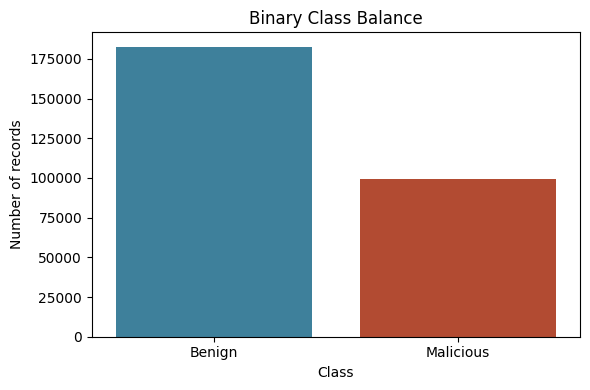

PosixPath('/home/shadow/Uni/Warwick/Studies/AI/coursework/no_dataset/figures/class_balance.png')

In [8]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

label_counts = class_counts.set_index("class")["records_found"]

plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette=["#2E86AB", "#C73E1D"], legend=False)
plt.title("Binary Class Balance")
plt.xlabel("Class")
plt.ylabel("Number of records")
plt.tight_layout()
class_balance_path = FIGURES_DIR / "class_balance.png"
plt.savefig(class_balance_path, dpi=200)
plt.show()

class_balance_path


## Train, Validation, And Test Split

The dataset is split into three parts:

- `70%` training data for fitting the models;
- `20%` validation data for comparing models and selecting the winner;
- `10%` final test data for the final held-out performance result.

The split is stratified, so the `Benign` and `Malicious` proportions are preserved across all three sets. This is important because the dataset is not perfectly balanced.


In [9]:
# Convert labels to Benign/Malicious and create the stratified train/validation/test split.
prepared = prepare_binary_dataset(cleaned, validation_size=0.2, test_size=0.1)

# Check that each split keeps roughly the same class proportions.
split_summary = pd.DataFrame([
    {"split": "Training", "rows": len(prepared.y_train), "benign": (prepared.y_train == "Benign").sum(), "malicious": (prepared.y_train == "Malicious").sum()},
    {"split": "Validation", "rows": len(prepared.y_validation), "benign": (prepared.y_validation == "Benign").sum(), "malicious": (prepared.y_validation == "Malicious").sum()},
    {"split": "Test", "rows": len(prepared.y_test), "benign": (prepared.y_test == "Benign").sum(), "malicious": (prepared.y_test == "Malicious").sum()},
])
split_summary["percentage_of_total"] = (split_summary["rows"] / split_summary["rows"].sum() * 100).round(2)
display_table(split_summary, "Stratified 70/20/10 split", hide_index=True)


split,rows,benign,malicious,percentage_of_total
Training,"196,157","126,630","69,527",70.0000
Validation,"56,046","36,181","19,865",20.0000
Test,"28,023","18,090","9,933",10.0000


## Leakage Check

This checks that the target label is not present in the feature matrix and that there are no identical feature rows shared between the train, validation, and test splits. This is useful because the final accuracy is very high.


In [10]:
# Rebuild the raw feature matrix so we can check for possible leakage manually.
raw_label_column = [column for column in cleaned.columns if column.strip().lower() == "label"][0]
raw_y = cleaned[raw_label_column].apply(lambda value: "Benign" if value == "BENIGN" else "Malicious")
raw_X = cleaned.drop(columns=[raw_label_column])
raw_X = raw_X[raw_X.select_dtypes(include=["number"]).columns.tolist()]
duplicate_feature_rows_removed = int(raw_X.duplicated(keep="first").sum())

# The target label must not appear as a model input feature.
label_removed = "Label" not in prepared.X_train.columns

# Hash each feature row and compare splits to confirm the same row is not shared across splits.
train_hashes = set(pd.util.hash_pandas_object(prepared.X_train, index=False))
validation_hashes = set(pd.util.hash_pandas_object(prepared.X_validation, index=False))
test_hashes = set(pd.util.hash_pandas_object(prepared.X_test, index=False))
train_validation_overlap = len(train_hashes.intersection(validation_hashes))
train_test_overlap = len(train_hashes.intersection(test_hashes))
validation_test_overlap = len(validation_hashes.intersection(test_hashes))

total_rows = prepared.X_train.shape[0] + prepared.X_validation.shape[0] + prepared.X_test.shape[0]

# Present the leakage checks as a table for the marker/report evidence.
leakage_check = pd.DataFrame([
    {"check": "Target label removed from feature matrix", "result": "Pass" if label_removed else "Fail", "value": label_removed},
    {"check": "Duplicate feature rows removed before split", "result": "Recorded", "value": duplicate_feature_rows_removed},
    {"check": "Training rows", "result": "Recorded", "value": prepared.X_train.shape[0]},
    {"check": "Validation rows", "result": "Recorded", "value": prepared.X_validation.shape[0]},
    {"check": "Test rows", "result": "Recorded", "value": prepared.X_test.shape[0]},
    {"check": "Train-validation duplicate feature overlap", "result": "Pass" if train_validation_overlap == 0 else "Review", "value": train_validation_overlap},
    {"check": "Train-test duplicate feature overlap", "result": "Pass" if train_test_overlap == 0 else "Review", "value": train_test_overlap},
    {"check": "Validation-test duplicate feature overlap", "result": "Pass" if validation_test_overlap == 0 else "Review", "value": validation_test_overlap},
])
display_table(leakage_check, "Leakage and split checks", hide_index=True)


check,result,value
Target label removed from feature matrix,Pass,True
Duplicate feature rows removed before split,Recorded,"1,691"
Training rows,Recorded,"196,157"
Validation rows,Recorded,"56,046"
Test rows,Recorded,"28,023"
Train-validation duplicate feature overlap,Pass,0
Train-test duplicate feature overlap,Pass,0
Validation-test duplicate feature overlap,Pass,0


## Train Models

This section trains several models so the final choice is evidence-based rather than assumed.

- `DummyClassifier` is the naive majority-class baseline.
- `Logistic Regression` is the simple linear baseline.
- `Random Forest`, `Extra Trees`, and `HistGradientBoostingClassifier` are stronger tree-based models that can capture non-linear patterns in network-flow features.

The validation set is used for model selection. The final test set is kept separate until reporting final performance.


In [11]:
# Build the candidate models and evaluate each one on the same train/validation/test split.
models = build_models()
results = train_and_evaluate(prepared, models)


Training dummy_most_frequent...
Training logistic_regression...
Training random_forest...
Training extra_trees...
Training hist_gradient_boosting...


## Hyperparameter Tuning

`HistGradientBoostingClassifier` is tuned with `GridSearchCV` using 3-fold cross-validation on a stratified training sample. The scoring metric is weighted F1-score, which is suitable here because the classes are not exactly equal in size.

The tuned model is added to the same `results` dictionary so it can be compared fairly against the default models.


In [12]:
# Show the tuning setup before running GridSearchCV.
tuning_setup = pd.DataFrame([
    {
        "cv_method": "GridSearchCV",
        "cv_folds": TUNING_CV_FOLDS,
        "scoring_metric": TUNING_SCORING,
        "tuning_rows": min(30_000, len(prepared.X_train)),
        "parameter_grid": HIST_GRADIENT_BOOSTING_PARAM_GRID,
    }
])
display_table(tuning_setup, "Hyperparameter tuning setup", hide_index=True)

# Tune the strongest model family using a stratified sample from the training set.
tuned_result, tuning_results = tune_hist_gradient_boosting(prepared, max_tuning_rows=30_000)

tuning_result_table = pd.DataFrame([
    {
        "model": "hist_gradient_boosting_tuning_check",
        "best_cv_weighted_f1": tuned_result["best_cv_weighted_f1"],
        "validation_accuracy_percent": round(tuned_result["validation_accuracy"] * 100, 4),
        "validation_weighted_f1": tuned_result["validation_classification_report"]["weighted avg"]["f1-score"],
        "test_accuracy_percent": round(tuned_result["test_accuracy"] * 100, 4),
        "test_weighted_f1": tuned_result["test_classification_report"]["weighted avg"]["f1-score"],
        "best_params": tuned_result["best_params"],
    }
])

# Keep the top tuning combinations so the report can show what GridSearchCV tested.
tuning_ranked_results = tuning_results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_learning_rate",
    "param_max_iter",
    "param_max_leaf_nodes",
]].head(8)

display_table(tuning_result_table, "Best tuned model result", hide_index=True)
display_table(tuning_ranked_results, "Top GridSearchCV parameter combinations", hide_index=True)


cv_method,cv_folds,scoring_metric,tuning_rows,parameter_grid
GridSearchCV,3,f1_weighted,"30,000","{'learning_rate': [0.05, 0.08], 'max_iter': [150, 200], 'max_leaf_nodes': [31, 63]}"


model,best_cv_weighted_f1,validation_accuracy_percent,validation_weighted_f1,test_accuracy_percent,test_weighted_f1,best_params
hist_gradient_boosting_tuning_check,0.9988,99.9732,0.9997,99.9500,0.9995,"{'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 63}"


rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_iter,param_max_leaf_nodes
1,0.9988,0.0001,0.0500,200,63
2,0.9988,0.0001,0.0800,150,63
2,0.9988,0.0001,0.0800,200,63
4,0.9987,0.0002,0.0500,150,63
5,0.9987,0.0002,0.0800,150,31
5,0.9987,0.0002,0.0800,200,31
7,0.9987,0.0002,0.0500,200,31
7,0.9987,0.0002,0.0500,150,31


## Compare Results

This table compares the models and chooses the winner using validation weighted F1-score. Weighted F1 is used because it balances precision and recall and also takes class sizes into account. In simple terms, it rewards a model that performs well on both `Benign` and `Malicious` records, not just the majority class.

Accuracy is still shown because it is easy to understand, but it is not used alone for model selection. The test metrics are reported after model selection as the final held-out performance evidence.


In [13]:
# Collect the main validation and test metrics from every trained model.
summary_rows = []
for name, result in results.items():
    validation_report = result["validation_classification_report"]
    test_report = result["test_classification_report"]
    summary_rows.append({
        "model": name,
        "validation_accuracy_percent": round(result["validation_accuracy"] * 100, 4),
        "validation_balanced_accuracy": result["validation_balanced_accuracy"],
        "validation_weighted_precision": validation_report["weighted avg"]["precision"],
        "validation_weighted_recall": validation_report["weighted avg"]["recall"],
        "validation_weighted_f1": validation_report["weighted avg"]["f1-score"],
        "test_accuracy_percent": round(result["test_accuracy"] * 100, 4),
        "test_balanced_accuracy": result["test_balanced_accuracy"],
        "test_weighted_precision": test_report["weighted avg"]["precision"],
        "test_weighted_recall": test_report["weighted avg"]["recall"],
        "test_weighted_f1": test_report["weighted avg"]["f1-score"],
        "cv_weighted_f1": result.get("best_cv_weighted_f1"),
        "best_params": result.get("best_params"),
    })

# Sort by validation weighted F1 so the strongest model appears first.
summary = pd.DataFrame(summary_rows).sort_values("validation_weighted_f1", ascending=False)
display_table(summary, "Model comparison sorted by validation weighted F1", hide_index=True)


model,validation_accuracy_percent,validation_balanced_accuracy,validation_weighted_precision,validation_weighted_recall,validation_weighted_f1,test_accuracy_percent,test_balanced_accuracy,test_weighted_precision,test_weighted_recall,test_weighted_f1,cv_weighted_f1,best_params
hist_gradient_boosting,99.9750,0.9998,0.9998,0.9998,0.9998,99.9536,0.9995,0.9995,0.9995,0.9995,-,-
random_forest,99.9447,0.9993,0.9994,0.9994,0.9994,99.9144,0.9989,0.9991,0.9991,0.9991,-,-
extra_trees,99.9161,0.9991,0.9992,0.9992,0.9992,99.8929,0.9987,0.9989,0.9989,0.9989,-,-
logistic_regression,96.2174,0.9663,0.9639,0.9622,0.9624,96.3708,0.9674,0.9652,0.9637,0.9639,-,-
dummy_most_frequent,64.5559,0.5000,0.4167,0.6456,0.5065,64.5541,0.5000,0.4167,0.6455,0.5065,-,-


### Model Comparison Graph

This graph compares the trained models using weighted F1 score, which is useful when the class sizes are not exactly equal.


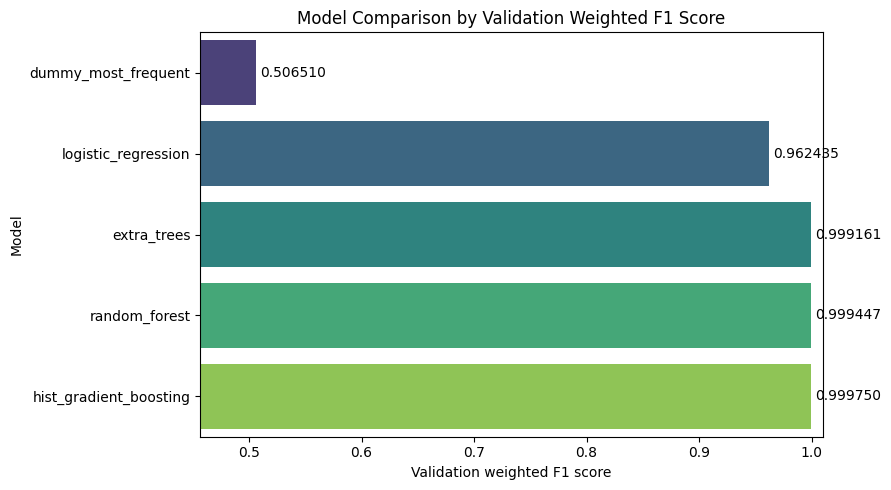

PosixPath('/home/shadow/Uni/Warwick/Studies/AI/coursework/no_dataset/figures/model_comparison_weighted_f1.png')

In [14]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_summary = summary.sort_values("validation_weighted_f1", ascending=True)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_summary,
    x="validation_weighted_f1",
    y="model",
    hue="model",
    palette="viridis",
    legend=False,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.6f", padding=3)
plt.title("Model Comparison by Validation Weighted F1 Score")
plt.xlabel("Validation weighted F1 score")
plt.ylabel("Model")
plt.xlim(max(0.0, plot_summary["validation_weighted_f1"].min() - 0.05), 1.01)
plt.tight_layout()
model_comparison_path = FIGURES_DIR / "model_comparison_weighted_f1.png"
plt.savefig(model_comparison_path, dpi=200)
plt.show()

model_comparison_path


In [15]:
confusion_tables = []
for name, result in results.items():
    validation_matrix = pd.DataFrame(
        result["validation_confusion_matrix"],
        index=["Actual Benign", "Actual Malicious"],
        columns=["Predicted Benign", "Predicted Malicious"],
    )
    test_matrix = pd.DataFrame(
        result["test_confusion_matrix"],
        index=["Actual Benign", "Actual Malicious"],
        columns=["Predicted Benign", "Predicted Malicious"],
    )
    display(Markdown(f"#### {name.replace('_', ' ').title()} - Validation Confusion Matrix"))
    display_table(validation_matrix.reset_index().rename(columns={"index": "actual_class"}), hide_index=True)
    display(Markdown(f"#### {name.replace('_', ' ').title()} - Test Confusion Matrix"))
    display_table(test_matrix.reset_index().rename(columns={"index": "actual_class"}), hide_index=True)


#### Dummy Most Frequent - Validation Confusion Matrix

actual_class,Predicted Benign,Predicted Malicious
Actual Benign,"36,181",0
Actual Malicious,"19,865",0


#### Dummy Most Frequent - Test Confusion Matrix

actual_class,Predicted Benign,Predicted Malicious
Actual Benign,"18,090",0
Actual Malicious,"9,933",0


#### Logistic Regression - Validation Confusion Matrix

...

actual_class,Predicted Benign,Predicted Malicious
Actual Benign,"18,082",8
Actual Malicious,22,"9,911"


#### Hist Gradient Boosting - Validation Confusion Matrix

actual_class,Predicted Benign,Predicted Malicious
Actual Benign,"36,171",10
Actual Malicious,4,"19,861"


#### Hist Gradient Boosting - Test Confusion Matrix

actual_class,Predicted Benign,Predicted Malicious
Actual Benign,"18,081",9
Actual Malicious,4,"9,929"


### Best Model Confusion Matrix Graph

This graph shows how many benign and malicious records the best model classified correctly or incorrectly.


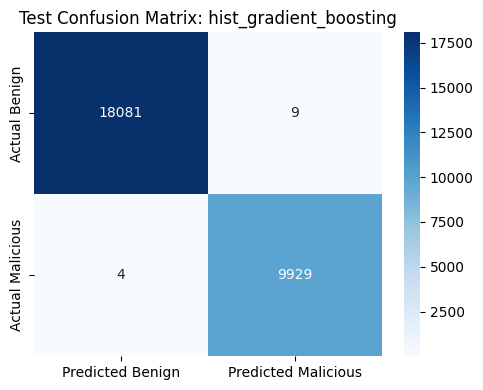

PosixPath('/home/shadow/Uni/Warwick/Studies/AI/coursework/no_dataset/figures/best_model_confusion_matrix.png')

In [16]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

winner = best_model_name(results)
confusion = results[winner]["test_confusion_matrix"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Benign", "Predicted Malicious"],
    yticklabels=["Actual Benign", "Actual Malicious"],
)
plt.title(f"Test Confusion Matrix: {winner}")
plt.tight_layout()
confusion_matrix_path = FIGURES_DIR / "best_model_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200)
plt.show()

confusion_matrix_path


## Feature Importance

Permutation importance estimates which features matter most by measuring how much the model score drops when each feature is randomly shuffled. If shuffling a feature causes a larger drop, the model was relying on that feature more strongly.

The table shows the top 15 features by mean decrease in weighted F1. For example, `Destination Port` has the largest value, so changing that feature disrupts the model more than changing the lower-ranked features. Values close to zero mean the model score barely changed when that feature was shuffled in this test sample.

This is useful for the report because it provides interpretability evidence: the model is not only producing high scores, it can also be discussed in terms of influential network-flow features.


feature,importance
Destination Port,0.044203
Init_Win_bytes_backward,0.023923
Init_Win_bytes_forward,0.019238
Fwd IAT Min,0.003330
Fwd Header Length,0.002001
Bwd Packet Length Std,0.001800
min_seg_size_forward,0.001201
Bwd Packet Length Min,0.001000
Bwd Packets/s,0.000400
Fwd Packet Length Max,0.000333


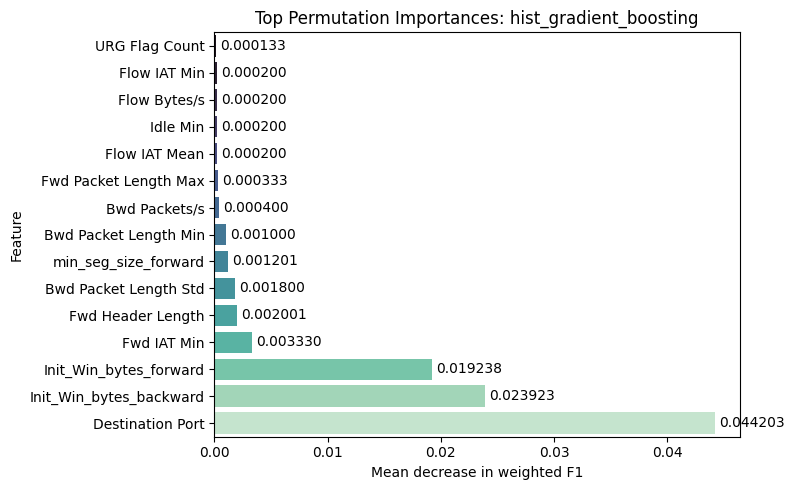

PosixPath('/home/shadow/Uni/Warwick/Studies/AI/coursework/no_dataset/figures/feature_importance.png')

In [17]:
# Select the winning model using the same validation metric as the comparison table.
winner = best_model_name(results)

# Use a test-set sample so permutation importance runs quickly in the notebook.
sample_size = min(5_000, len(prepared.X_test))
X_sample = prepared.X_test.sample(sample_size, random_state=42)
y_sample = prepared.y_test.loc[X_sample.index]

# Shuffle one feature at a time and measure how much weighted F1 drops.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
    importance = permutation_importance(
        results[winner]["model"],
        X_sample,
        y_sample,
        scoring="f1_weighted",
        n_repeats=3,
        random_state=42,
        n_jobs=-1,
    )

# Larger importance values mean the model depended more on that feature.
feature_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "importance": importance.importances_mean,
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(15)
display_table(top_features, "Top 15 permutation feature importances", hide_index=True, precision=6)

# Save the top-feature graph for the report.
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=top_features.sort_values("importance"), x="importance", y="feature", hue="feature", palette="mako", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.6f", padding=3)
plt.title(f"Top Permutation Importances: {winner}")
plt.xlabel("Mean decrease in weighted F1")
plt.ylabel("Feature")
plt.tight_layout()
feature_importance_path = FIGURES_DIR / "feature_importance.png"
plt.savefig(feature_importance_path, dpi=200)
plt.show()

feature_importance_path


## Save Best Model And Reproduce Test Accuracy

The best model is saved as a `.joblib` file, then loaded back from disk and tested again on the held-out test set.

This proves that the submitted model file can be reloaded and used to reproduce the reported final test metrics.


In [18]:
# Create the models folder if needed, then save the selected best model.
MODELS_DIR.mkdir(parents=True, exist_ok=True)

winner = best_model_name(results)
model_path = MODELS_DIR / f"{winner}.joblib"
save_model(results[winner]["model"], model_path)

# Reload the saved model and rerun predictions to prove the saved file works.
reloaded_model = joblib.load(model_path)
reloaded_predictions = reloaded_model.predict(prepared.X_test)
reloaded_report = classification_report(
    prepared.y_test,
    reloaded_predictions,
    output_dict=True,
    zero_division=0,
)
reloaded_confusion = confusion_matrix(
    prepared.y_test,
    reloaded_predictions,
    labels=["Benign", "Malicious"],
)

# Summarise the reproducibility check for the notebook/report.
best_model_summary = pd.DataFrame([
    {
        "best_model": winner,
        "selection_metric": "validation_weighted_f1",
        "saved_model_path": str(model_path),
        "test_accuracy_percent": round(accuracy_score(prepared.y_test, reloaded_predictions) * 100, 4),
        "test_weighted_f1": reloaded_report["weighted avg"]["f1-score"],
    }
])

reloaded_confusion_table = pd.DataFrame(
    reloaded_confusion,
    index=["Actual Benign", "Actual Malicious"],
    columns=["Predicted Benign", "Predicted Malicious"],
).reset_index().rename(columns={"index": "actual_class"})

display_table(best_model_summary, "Saved and reloaded best model", hide_index=True)
display_table(class_counts, "Final binary class counts used in the experiment", hide_index=True)
display_table(reloaded_confusion_table, "Reloaded model test confusion matrix", hide_index=True)


best_model,selection_metric,saved_model_path,test_accuracy_percent,test_weighted_f1
hist_gradient_boosting,validation_weighted_f1,/home/shadow/Uni/Warwick/Studies/AI/coursework/no_dataset/models/hist_gradient_boosting.joblib,99.9536,0.9995


class,records_found,percentage
Benign,"182,590",64.7700
Malicious,"99,327",35.2300


actual_class,Predicted Benign,Predicted Malicious
Actual Benign,"18,081",9
Actual Malicious,4,"9,929"
